In [20]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# LOAD GENOTOX DATABASE
# ==========================================

genotox = pd.read_excel("Genotox.xlsx")

# Check dimensions

print("Rows and Columns:")
print(genotox.shape)

# Check column names

print("Columns:")
print(genotox.columns.tolist())

Rows and Columns:
(17927, 45)
Columns:
['SUB_NAME', 'SUB_ECSUBINVENTENTRYREF', 'SUB_CASNUMBER', 'SUB_TYPE', 'QUALIFIER', 'COM_NAME', 'COM_ECSUBINVENTENTRYREF', 'COM_CASNUMBER', 'IUPACNAME', 'COMPARAMNAME', 'MOLECULARFORMULA', 'SMILESNOTATION', 'INCHI', 'COM_TYPE', 'COM_STRUCTURESHOWN', 'SMILESNOTATIONSOURCE', 'INCHI_NOTATIONSOURCE', 'GENOTOX_ENDPOINT', 'TESTTYPE', 'METHOD_TYPE', 'GUIDELINE_QUALIFIER', 'GENOTOXGUIDELINEFULLTXT', 'DEVIATION', 'ACCEPTABILITY', 'SPECIES', 'STRAIN', 'NUMBER_INDIVIDUALS', 'SEX', 'ROUTE', 'EXP_PERIOD', 'EXPPERIODUNIT', 'CONTROL', 'MET_INDICATOR', 'RESULTS', 'MOUSELYMPHTEST', 'INVIVOTISSUEEXP', 'DARAuthor', 'DARTitle', 'DARYear', 'OpinionType', 'OpinionAuthor', 'OpinionTitle', 'PUBLICATIONDATE', 'OpinionPubYear', 'DOI']


Number of unique substances:
293

Substance Types:
                                            SUB_TYPE  COUNT
0    complex product: derived from botanical sources      4
1  complex product: microorganisms or derived fro...      1
2                             mixture or formulation      7
3                             single chemical entity    289


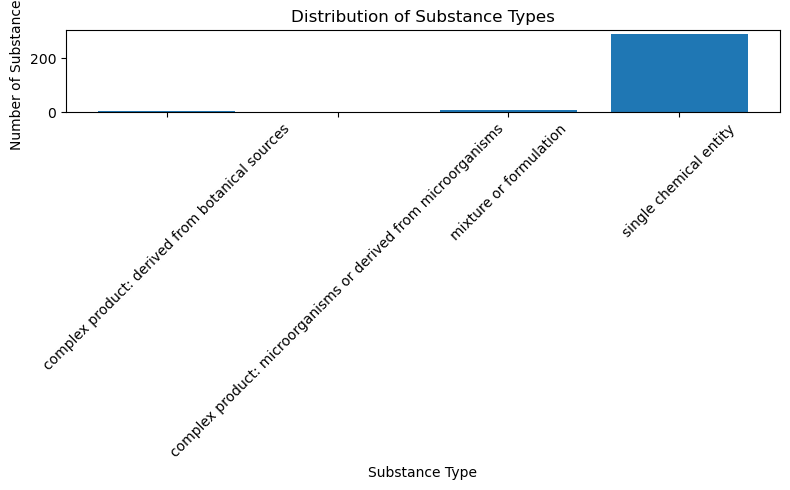

In [21]:
# ==========================================
# QUESTION 1(a)
#
# How many substances are included in the
# Genotox database?
#
# Which type(s) of substances are they?
#
# Provide a graphical representation.
# ==========================================

# Number of unique substances

n_substances = genotox["SUB_NAME"].nunique()

print("Number of unique substances:")
print(n_substances)

# Count substance types

substance_types = (
    genotox[["SUB_NAME", "SUB_TYPE"]]
    .drop_duplicates()
    .groupby("SUB_TYPE")
    .size()
    .reset_index(name="COUNT")
)

print("\nSubstance Types:")
print(substance_types)

# Create bar chart

plt.figure(figsize=(8,5))

plt.bar(
    substance_types["SUB_TYPE"],
    substance_types["COUNT"]
)

plt.title("Distribution of Substance Types")
plt.xlabel("Substance Type")
plt.ylabel("Number of Substances")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("Question1A_SubstanceTypes.png")

plt.show()

In [22]:
# ==========================================
# QUESTION 1(b)
#
# Create a table containing:
# - substance name
# - termCode
# - CAS number
# - total number of assays
# - positive results
# - negative results
# ==========================================

# Merge with PARAM

POSITIVE_RESULTS=("POSITIVE", "sum")
NEGATIVE_RESULTS=("NEGATIVE", "sum")

In [26]:
# ==========================================
# QUESTION 1(b)

# Merge Genotox data with PARAM catalogue
# using CAS Number to obtain termCode

merged = genotox.merge(
    param[["CAS", "termCode"]],
    left_on="SUB_CASNUMBER",
    right_on="CAS",
    how="left"
)

# Create Positive Result indicator

merged["POSITIVE"] = merged["RESULTS"].astype(str).str.contains(
    "positive",
    case=False,
    na=False
)

# Create Negative Result indicator

merged["NEGATIVE"] = merged["RESULTS"].astype(str).str.contains(
    "negative",
    case=False,
    na=False
)

# Create summary table

summary = (
    merged.groupby(
        ["SUB_NAME", "termCode", "SUB_CASNUMBER"]
    )
    .agg(
        TOTAL_ASSAYS=("RESULTS", "count"),
        POSITIVE_RESULTS=("POSITIVE", "sum"),
        NEGATIVE_RESULTS=("NEGATIVE", "sum")
    )
    .reset_index()
)

# Rename columns

summary.columns = [
    "SUBSTANCE_NAME",
    "TERMCODE",
    "CAS_NUMBER",
    "TOTAL_ASSAYS",
    "POSITIVE_RESULTS",
    "NEGATIVE_RESULTS"
]

# Save output

summary.to_excel(
    "Question1B_SubstanceSummary.xlsx",
    index=False
)

# Display first 5 rows

print(summary.head())

                                    SUBSTANCE_NAME         TERMCODE  \
0                          1,4-Dimethylnaphthalene  RF-00004728-PAR   
1                             1-Methylcyclopropene  RF-0005-001-PPP   
2                            1-Naphthylacetic acid  RF-0007-001-PPP   
3  2,4,6,8-Tetramethyl-1,3,5,7-tetraoxacyclooctane  RF-0282-001-PPP   
4                                            2,4-D  RF-0010-003-PPP   

  CAS_NUMBER  TOTAL_ASSAYS  POSITIVE_RESULTS  NEGATIVE_RESULTS  
0   571-58-4            32                 2                30  
1  3100-04-7            16                 0                16  
2    86-87-3            54                 1                51  
3   108-62-3            33                 0                33  
4    94-75-7            69                21                47  


In [24]:
# ==========================================
# QUESTION 1(c)
#
# For substances with an EFSA opinion
# published after 2013, provide the same
# information in a well-formatted HTML table.
# ==========================================

# Step 1: Keep only records with
# Opinion Publication Year after 2013

after2013 = merged[
    pd.to_numeric(
        merged["OpinionPubYear"],
        errors="coerce"
    ) > 2013
]

# Step 2: Create summary table

summary2013 = (
    after2013.groupby(
        ["SUB_NAME", "termCode", "SUB_CASNUMBER"]
    )
    .agg(
        TOTAL_ASSAYS=("RESULTS", "count"),
        POSITIVE_RESULTS=("POSITIVE", "sum"),
        NEGATIVE_RESULTS=("NEGATIVE", "sum")
    )
    .reset_index()
)

# Step 3: Rename columns

summary2013.columns = [
    "SUBSTANCE_NAME",
    "TERMCODE",
    "CAS_NUMBER",
    "TOTAL_ASSAYS",
    "POSITIVE_RESULTS",
    "NEGATIVE_RESULTS"
]

# Step 4: Sort by substance name

summary2013 = summary2013.sort_values(
    "SUBSTANCE_NAME"
)

# Step 5: Export as HTML table

summary2013.to_html(
    "Question1C_Post2013.html",
    index=False
)

# Step 6: Display first 10 rows

print(summary2013.head(10))

         SUBSTANCE_NAME         TERMCODE   CAS_NUMBER  TOTAL_ASSAYS  \
0                 2,4-D  RF-0010-003-PPP      94-75-7            69   
1                2,4-DB  RF-00004646-PAR      94-82-6            84   
2  Acibenzolar-S-methyl  RF-0016-002-PPP  135158-54-2            96   
3            Amisulbrom  RF-0470-001-PPP  348635-87-0            39   
4              Amitrole  RF-0025-001-PPP      61-82-5           228   
5             Bentazone  RF-0042-002-PPP   25057-89-0           161   
6     Beta-Cypermethrin  RF-0112-003-PPP   65731-84-2            19   
7   Carfentrazone-ethyl  RF-0070-003-PPP  128639-02-1           213   
8      Cyantraniliprole  RF-00003336-PAR  736994-63-1           104   
9       Cyhalofop-butyl  RF-00003378-PAR  122008-85-9            35   

   POSITIVE_RESULTS  NEGATIVE_RESULTS  
0                21                47  
1                 9                74  
2                 5                90  
3                 0                39  
4                2

In [25]:
# ==========================================
# QUESTION 1(d)
#
# Define what constitutes a study using
# available fields.
# ==========================================

study_fields = [
    "SUB_NAME",
    "TESTTYPE",
    "GENOTOX_ENDPOINT",
    "SPECIES",
    "STRAIN",
    "GENOTOXGUIDELINEFULLTXT",
    "DARTitle"
]

study_output = (
    genotox.groupby(study_fields)
           .size()
           .reset_index(name="N_RECORDS")
)

study_output.to_excel(
    "Question1D_StudyDefinition.xlsx",
    index=False
)

study_output.head()

,SUB_NAME,TESTTYPE,GENOTOX_ENDPOINT,SPECIES,STRAIN,GENOTOXGUIDELINEFULLTXT,DARTitle,N_RECORDS
0,"1,4-Dimethylnaphthalene","DNA damage and repair assay, unscheduled DNA s...",DNA damage and/or repair,Rat (as animal),hepatocytes,OECD Guideline 482 (Genetic Toxicology: DNA Da...,"1,4-Dimethylnaphthalene (Final Addendum)",1
1,"1,4-Dimethylnaphthalene",Mammalian erythrocyte micronucleus test,chromosome aberration,House mouse (as animal),CD-1,OECD Guideline 474 (Mammalian Erythrocyte Micr...,"1,4-Dimethylnaphthalene (Final Addendum)",6
2,"1,4-Dimethylnaphthalene",bacterial reverse mutation assay,gene mutation,Salmonella typhimurium (as organism),TA 100,OECD Guideline 471 (Bacterial Reverse Mutation...,"1,4-Dimethylnaphthalene (Final Addendum)",4
3,"1,4-Dimethylnaphthalene",bacterial reverse mutation assay,gene mutation,Salmonella typhimurium (as organism),TA 102,OECD Guideline 471 (Bacterial Reverse Mutation...,"1,4-Dimethylnaphthalene (Final Addendum)",2
4,"1,4-Dimethylnaphthalene",bacterial reverse mutation assay,gene mutation,Salmonella typhimurium (as organism),TA 1535,OECD Guideline 471 (Bacterial Reverse Mutation...,"1,4-Dimethylnaphthalene (Final Addendum)",4
